In [1]:
import pandas as pd

df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'online_retail_II.csv'

In [2]:
import os
print(os.getcwd())

C:\Users\amaya\OneDrive\Desktop\customer_segmentation_project


In [3]:
print(os.listdir())

['.ipynb_checkpoints', 'customer_segmentation.ipynb']


In [4]:
print(os.listdir())

['.ipynb_checkpoints', 'customer_segmentation.ipynb', 'online_retail_II.csv']


In [5]:
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print(df.shape)
df.info()

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
df = df.dropna(subset=['Customer ID'])

df = df[~df['Invoice'].astype(str).str.startswith('C')]

df = df[df['Quantity'] > 0]

df = df[df['Price'] > 0]

print(df.shape)

(805549, 8)


In [8]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

26124
(779425, 8)


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


In [11]:
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

df['TotalPrice'] = df['Quantity'] * df['Price']

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   
    'Invoice': 'nunique',                                        
    'TotalPrice': 'sum'                                          
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.856701,1.254496,3.206219
12347.0,-2.151979,0.800166,1.215993
12348.0,-0.079138,0.299207,0.573185
12349.0,-0.935308,0.073946,1.139846
12350.0,0.824527,-1.058146,-0.723024


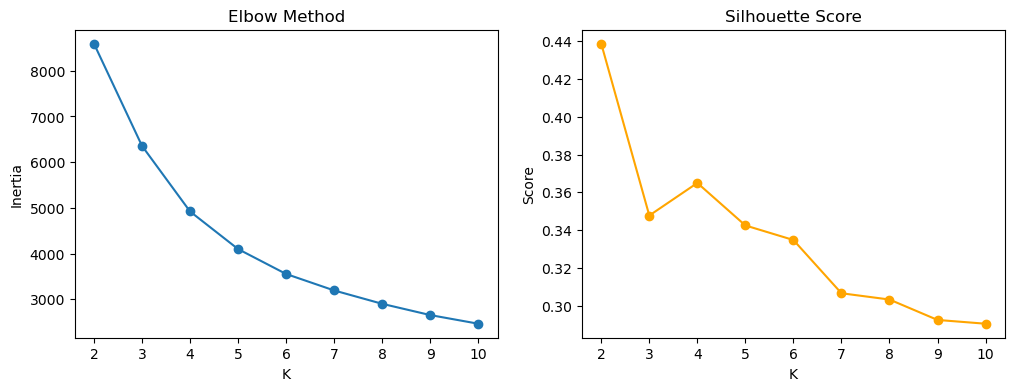

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('K')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('K')
ax[1].set_ylabel('Score')

plt.show()

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,2
12348.0,75,5,2019.40,3
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [17]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'CustomerCount'})

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,394.946275,1.377598,317.081501,1973
1,28.304800,3.053600,857.491434,1250
2,27.711538,19.275920,10731.162991,1196
3,230.072653,5.058259,1948.503933,1459


In [18]:
cluster_labels = {
    0: 'Lost Customers',
    1: 'New Customers',
    2: 'Champions',
    3: 'At-Risk Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,2,Champions
12347.0,2,8,4921.53,2,Champions
12348.0,75,5,2019.40,3,At-Risk Customers
12349.0,19,4,4428.69,1,New Customers
12350.0,310,1,334.40,0,Lost Customers


In [19]:
rfm.to_csv('rfm_segmented.csv')
print("Saved")

Saved


In [20]:
print(os.listdir())

['.ipynb_checkpoints', 'customer_segmentation.ipynb', 'online_retail_II.csv', 'rfm_segmented.csv']
